Teaching Assistance Performance Prediction


🎓 Problem Statement

The objective of this project is to analyze Teaching Assistant evaluation data and build a Machine Learning model capable of predicting the performance category of teaching assistants.

The target classes are:

Low
Medium
High

📌 Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

📌 Load Dataset

In [2]:
df = pd.read_csv('/content/tae.csv')

📌 Display Dataset


In [3]:
print(df.head())

   1  23   3  1.1  19  3.1
0  2  15   3    1  17    3
1  1  23   3    2  49    3
2  1   5   2    2  33    3
3  2   7  11    2  55    3
4  2  23   3    1  20    3


In [4]:
print(df.shape)

(150, 6)


In [5]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   1       150 non-null    int64
 1   23      150 non-null    int64
 2   3       150 non-null    int64
 3   1.1     150 non-null    int64
 4   19      150 non-null    int64
 5   3.1     150 non-null    int64
dtypes: int64(6)
memory usage: 7.2 KB
None


📌 Rename Columns

In [6]:
df.columns = ['Native_teacher', 'Instructor', 'Course', 'Semester', 'Class_size', 'Class_attribute']

📌 Check Missing Values

In [7]:
print(df.isnull().sum())

Native_teacher     0
Instructor         0
Course             0
Semester           0
Class_size         0
Class_attribute    0
dtype: int64


📌 Statistical Summary

In [8]:
print(df.describe())

       Native_teacher  Instructor      Course    Semester  Class_size  \
count      150.000000  150.000000  150.000000  150.000000  150.000000   
mean         1.813333   13.580000    8.140000    1.853333   27.926667   
std          0.390949    6.805318    7.034937    0.354958   12.916405   
min          1.000000    1.000000    1.000000    1.000000    3.000000   
25%          2.000000    8.000000    3.000000    2.000000   19.000000   
50%          2.000000   13.000000    4.500000    2.000000   27.000000   
75%          2.000000   20.000000   15.000000    2.000000   37.000000   
max          2.000000   25.000000   26.000000    2.000000   66.000000   

       Class_attribute  
count       150.000000  
mean          2.013333  
std           0.819123  
min           1.000000  
25%           1.000000  
50%           2.000000  
75%           3.000000  
max           3.000000  


📌 Exploratory Data Analysis (EDA)

Class Attribute Distribution

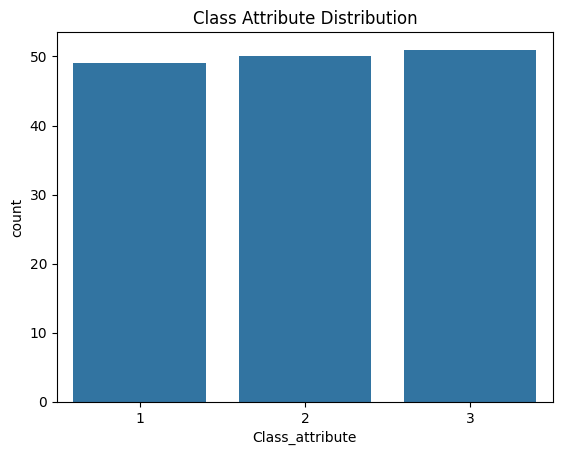

In [9]:
sns.countplot(x='Class_attribute', data=df)
plt.title('Class Attribute Distribution')
plt.show()

Semester Distribution

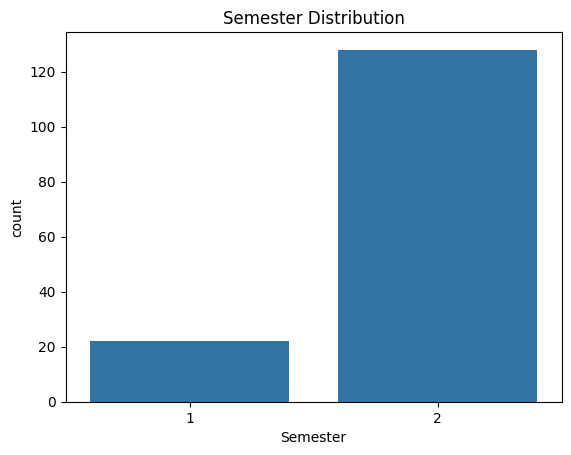

In [10]:
sns.countplot(x='Semester', data=df)
plt.title('Semester Distribution')
plt.show()

Native Teacher Distribution

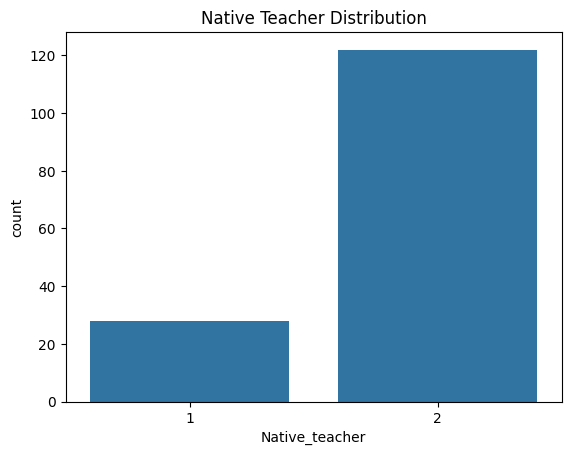

In [11]:
sns.countplot(x='Native_teacher', data=df)
plt.title('Native Teacher Distribution')
plt.show()

Class Size Distribution

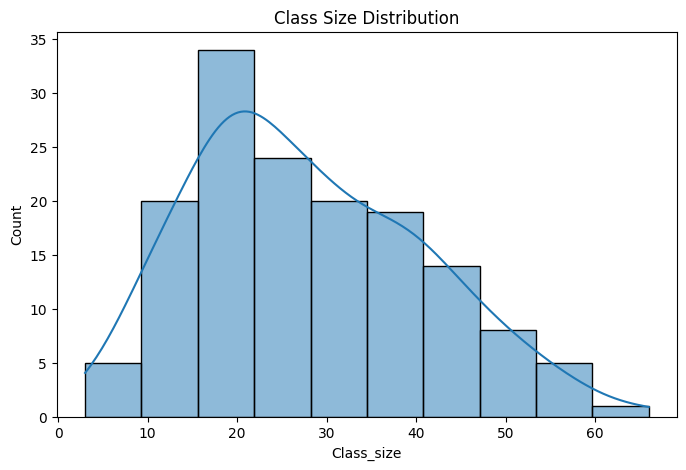

In [12]:
plt.figure(figsize=(8,5))
sns.histplot(df['Class_size'], kde=True)
plt.title('Class Size Distribution')
plt.show()

📌 Correlation Heatmap

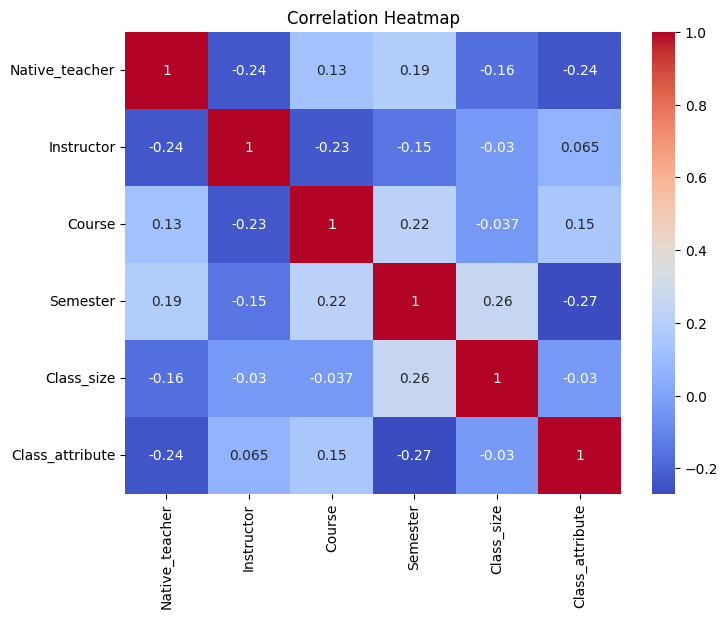

In [13]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

📌 Label Encoding

In [14]:
le = LabelEncoder()

for col in df.columns:
    df[col] = le.fit_transform(df[col])

📌 Split Features and Target

In [15]:
X = df.drop('Class_attribute', axis=1)
y = df['Class_attribute']

📌 Train Test Split

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

📌 Logistic Regression Model

In [17]:
lr = LogisticRegression()
lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

print('Logistic Regression Accuracy:', accuracy_score(y_test, lr_pred))
print(classification_report(y_test, lr_pred))

Logistic Regression Accuracy: 0.5333333333333333
              precision    recall  f1-score   support

           0       0.67      0.71      0.69        14
           1       0.45      0.45      0.45        11
           2       0.25      0.20      0.22         5

    accuracy                           0.53        30
   macro avg       0.46      0.46      0.46        30
weighted avg       0.52      0.53      0.53        30



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


📌 Decision Tree Classifier

In [18]:
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

print('Decision Tree Accuracy:', accuracy_score(y_test, dt_pred))
print(classification_report(y_test, dt_pred))

Decision Tree Accuracy: 0.7
              precision    recall  f1-score   support

           0       0.82      0.64      0.72        14
           1       0.88      0.64      0.74        11
           2       0.45      1.00      0.62         5

    accuracy                           0.70        30
   macro avg       0.72      0.76      0.69        30
weighted avg       0.78      0.70      0.71        30



📌 Random Forest Classifier

In [19]:
rf = RandomForestClassifier()
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print('Random Forest Accuracy:', accuracy_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred))

Random Forest Accuracy: 0.7333333333333333
              precision    recall  f1-score   support

           0       0.83      0.71      0.77        14
           1       0.78      0.64      0.70        11
           2       0.56      1.00      0.71         5

    accuracy                           0.73        30
   macro avg       0.72      0.78      0.73        30
weighted avg       0.77      0.73      0.73        30



📌 KNN Classifier

In [20]:
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)

knn_pred = knn.predict(X_test)

print('KNN Accuracy:', accuracy_score(y_test, knn_pred))
print(classification_report(y_test, knn_pred))

KNN Accuracy: 0.43333333333333335
              precision    recall  f1-score   support

           0       0.67      0.43      0.52        14
           1       0.60      0.27      0.38        11
           2       0.25      0.80      0.38         5

    accuracy                           0.43        30
   macro avg       0.51      0.50      0.43        30
weighted avg       0.57      0.43      0.44        30



📌 Support Vector Machine (SVM)

In [21]:
svm = SVC()
svm.fit(X_train, y_train)

svm_pred = svm.predict(X_test)

print('SVM Accuracy:', accuracy_score(y_test, svm_pred))
print(classification_report(y_test, svm_pred))

SVM Accuracy: 0.2
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        14
           1       0.40      0.18      0.25        11
           2       0.16      0.80      0.27         5

    accuracy                           0.20        30
   macro avg       0.19      0.33      0.17        30
weighted avg       0.17      0.20      0.14        30



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


📌 Model Comparison

In [22]:
models = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest', 'KNN', 'SVM'],
    'Accuracy': [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, knn_pred),
        accuracy_score(y_test, svm_pred)
    ]
})

print(models)

                 Model  Accuracy
0  Logistic Regression  0.533333
1        Decision Tree  0.700000
2        Random Forest  0.733333
3                  KNN  0.433333
4                  SVM  0.200000


📌 Visualize Model Accuracy

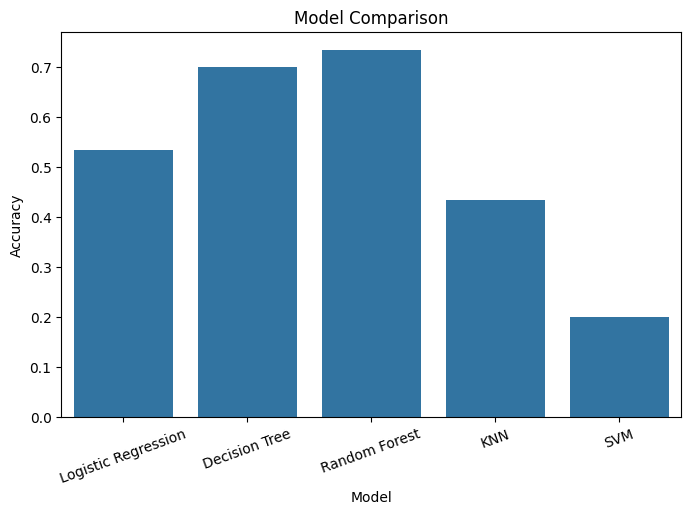

In [23]:
plt.figure(figsize=(8,5))
sns.barplot(x='Model', y='Accuracy', data=models)
plt.xticks(rotation=20)
plt.title('Model Comparison')
plt.show()

📌 Best Model Selection

In [24]:
best_model = models.sort_values(by='Accuracy', ascending=False)
print(best_model)

                 Model  Accuracy
2        Random Forest  0.733333
1        Decision Tree  0.700000
0  Logistic Regression  0.533333
3                  KNN  0.433333
4                  SVM  0.200000


📌 Confusion Matrix

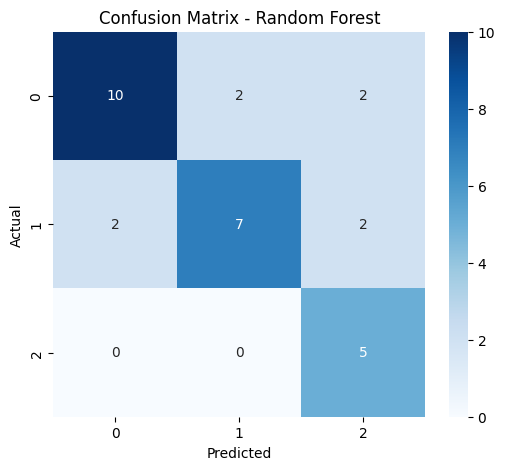

In [25]:
cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

📌 Challenges Faced

Challenges



*   Small dataset size
*   Encoding categorical variables

*   Feature selection
*   Class imbalance handling

Techniques Used



*   Label Encoding for categorical data
*   Multiple model comparison

*   Train-test split for validation
*   Visualization using Seaborn and Matplotlib










📌 Conclusion

The project successfully analyzed Teaching Assistant evaluation data and built multiple Machine Learning models to predict TA performance.

Among all models, the best-performing model was selected based on accuracy and performance metrics.

This model can help educational institutions analyze teaching effectiveness and improve academic quality.